<a href="https://colab.research.google.com/github/mannan234-cmd/InternCircle-Data-Science-AI/blob/main/InternCircle_Task_04_Sales_Trend_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# InternCircle – Task 4
## Customer Churn / Sales Trend Analysis

### Project: E-Commerce Sales Trend Analysis

This project performs end-to-end analysis of an e-commerce sales dataset to identify revenue trends, top-performing products or customer segments, and important business patterns.

### Objectives
- Clean and prepare the sales dataset.
- Perform feature engineering and date extraction.
- Calculate sales and revenue trends.
- Create pivot tables for business analysis.
- Identify top customers, products, and categories.
- Analyze monthly and yearly sales trends.
- Generate actionable business recommendations.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (541909, 8)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
# Display column names

print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [7]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 5268


In [8]:
# Remove duplicate records

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (536641, 8)


In [9]:
# Check missing values

print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
dtype: int64


In [10]:
# Remove transactions without CustomerID

df = df.dropna(subset=["CustomerID"])

print("Dataset shape after removing missing CustomerID:", df.shape)

Dataset shape after removing missing CustomerID: (401604, 8)


In [11]:
df = df.dropna(subset=["Description"])

In [12]:
# Keep only valid sales transactions

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (392692, 8)


In [13]:
# Convert InvoiceDate to datetime

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print(df["InvoiceDate"].dtype)

datetime64[ns]


In [14]:
# Calculate revenue

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [15]:
# Extract date features

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Month_Name"] = df["InvoiceDate"].dt.month_name()
df["Day"] = df["InvoiceDate"].dt.day

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1


In [16]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (392692, 13)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
Month_Name     0
Day            0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
Revenue               float64
Year                    int32
Month                   int32
Month_Name             object
Day                     int32
dtype: object


In [17]:
print("Dataset columns:")
print(df.columns.tolist())

Dataset columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month', 'Month_Name', 'Day']


In [18]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [19]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [20]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (392692, 13)


In [21]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("InvoiceDate converted successfully!")
print(df["InvoiceDate"].dtype)

InvoiceDate converted successfully!
datetime64[ns]


In [22]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Revenue feature created successfully!")

df[["Quantity", "UnitPrice", "Revenue"]].head()

Revenue feature created successfully!


,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [23]:
df_sales = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

print("Original rows:", len(df))
print("Valid sales rows:", len(df_sales))

Original rows: 392692
Valid sales rows: 392692


In [24]:
df_sales["Year"] = df_sales["InvoiceDate"].dt.year
df_sales["Month"] = df_sales["InvoiceDate"].dt.month
df_sales["Month_Name"] = df_sales["InvoiceDate"].dt.strftime("%B")
df_sales["Day"] = df_sales["InvoiceDate"].dt.day
df_sales["Day_Name"] = df_sales["InvoiceDate"].dt.strftime("%A")

print("Date features created successfully!")

df_sales[
    ["InvoiceDate", "Year", "Month", "Month_Name", "Day", "Day_Name"]
].head()

Date features created successfully!


,InvoiceDate,Year,Month,Month_Name,Day,Day_Name
0,2010-12-01 08:26:00,2010,12,December,1,Wednesday
1,2010-12-01 08:26:00,2010,12,December,1,Wednesday
2,2010-12-01 08:26:00,2010,12,December,1,Wednesday
3,2010-12-01 08:26:00,2010,12,December,1,Wednesday
4,2010-12-01 08:26:00,2010,12,December,1,Wednesday


In [25]:
total_revenue = df_sales["Revenue"].sum()
total_orders = df_sales["InvoiceNo"].nunique()
total_customers = df_sales["CustomerID"].nunique()
total_products = df_sales["StockCode"].nunique()

average_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £8,887,208.89
Total Orders: 18,532
Total Customers: 4,338
Total Products: 3,665
Average Order Value: £479.56


In [26]:
monthly_revenue = pd.pivot_table(
    df_sales,
    values="Revenue",
    index=["Year", "Month"],
    aggfunc="sum"
)

monthly_revenue = monthly_revenue.rename(
    columns={"Revenue": "Total_Revenue"}
)

monthly_revenue

Total_Revenue
Year Month               
2010 12        570422.730
2011 1         568101.310
     2         446084.920
     3         594081.760
     4         468374.331
     5         677355.150
     6         660046.050
     7         598962.901
     8         644051.040
     9         950690.202
     10       1035642.450
     11       1156205.610
     12        517190.440

In [27]:
monthly_trend = (
    df_sales
    .groupby(df_sales["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
)

monthly_trend

,Revenue
InvoiceDate,
2010-12,570422.730
2011-01,568101.310
2011-02,446084.920
2011-03,594081.760
2011-04,468374.331
2011-05,677355.150
2011-06,660046.050
2011-07,598962.901
2011-08,644051.040


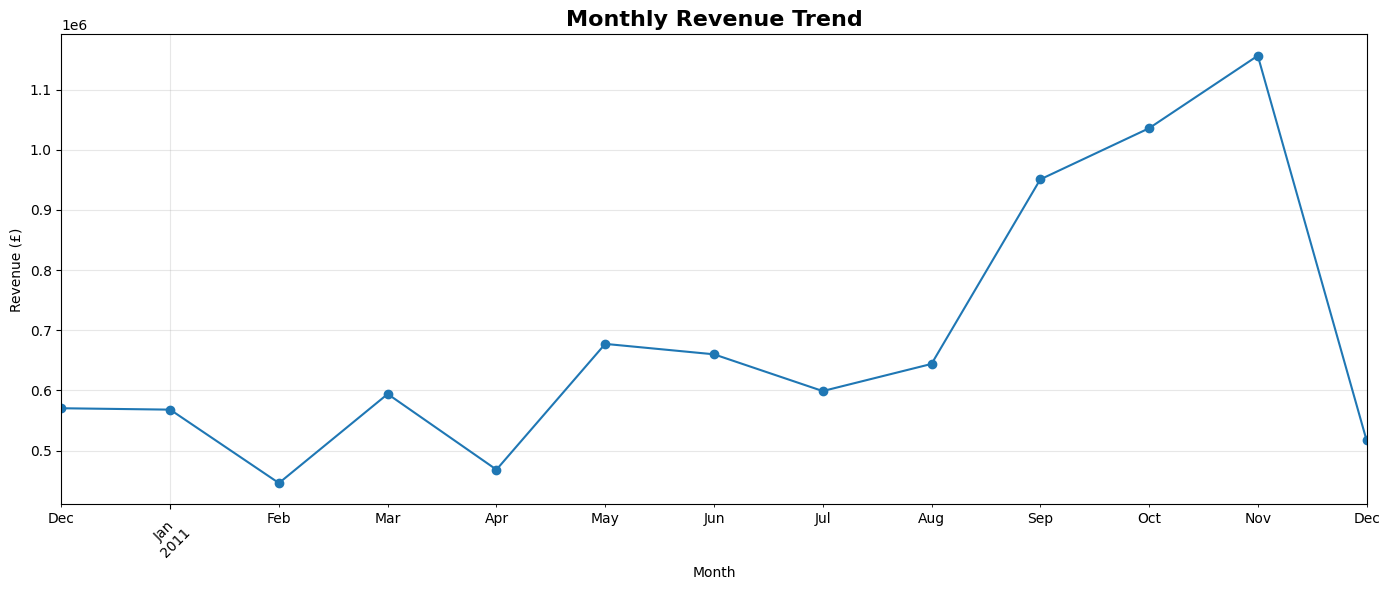

In [28]:
plt.figure(figsize=(14, 6))

monthly_trend.plot(marker="o")

plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
top_products = (
    df_sales
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Revenue
Description,
"PAPER CRAFT , LITTLE BIRDIE",168469.60
REGENCY CAKESTAND 3 TIER,142264.75
WHITE HANGING HEART T-LIGHT HOLDER,100392.10
JUMBO BAG RED RETROSPOT,85040.54
MEDIUM CERAMIC TOP STORAGE JAR,81416.73
POSTAGE,77803.96
PARTY BUNTING,68785.23
ASSORTED COLOUR BIRD ORNAMENT,56413.03
Manual,53419.93


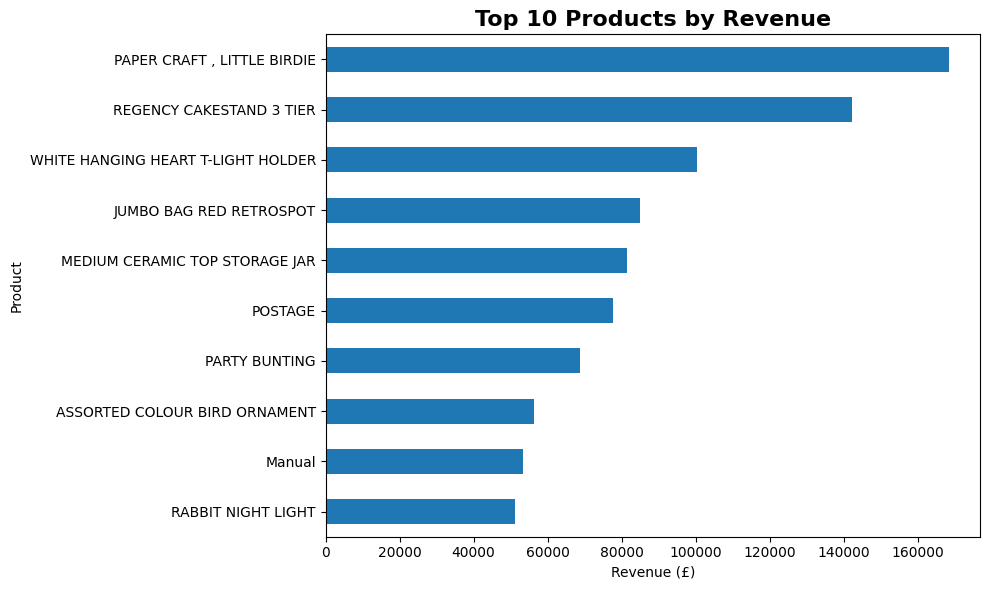

In [30]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [31]:
country_revenue = (
    df_sales
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

,Revenue
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


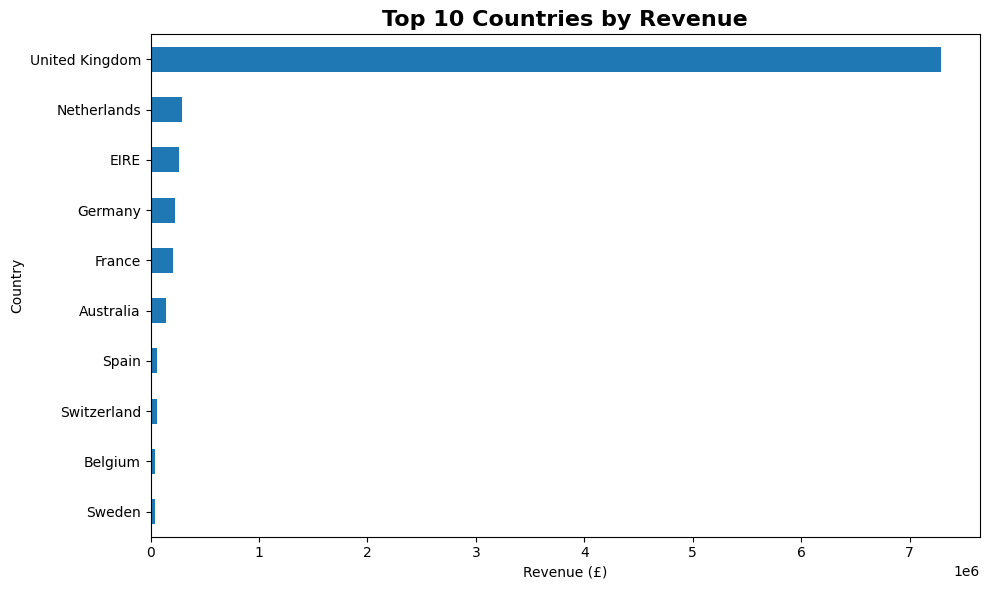

In [32]:
plt.figure(figsize=(10, 6))

country_revenue.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [33]:
customer_sales = df_sales[df_sales["CustomerID"].notna()].copy()

customer_summary = customer_sales.groupby("CustomerID").agg(
    Total_Revenue=("Revenue", "sum"),
    Total_Orders=("InvoiceNo", "nunique"),
    Total_Quantity=("Quantity", "sum")
).reset_index()

customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Revenue"] / customer_summary["Total_Orders"]
)

customer_summary.head()

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value
0,12346.0,77183.60,1,74215,77183.600000
1,12347.0,4310.00,7,2458,615.714286
2,12348.0,1797.24,4,2341,449.310000
3,12349.0,1757.55,1,631,1757.550000
4,12350.0,334.40,1,197,334.400000


In [34]:
q33 = customer_summary["Total_Revenue"].quantile(1/3)
q66 = customer_summary["Total_Revenue"].quantile(2/3)

customer_summary["Customer_Segment"] = np.select(
    [
        customer_summary["Total_Revenue"] <= q33,
        customer_summary["Total_Revenue"] <= q66
    ],
    [
        "Low Value",
        "Medium Value"
    ],
    default="High Value"
)

customer_summary.head()

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,Average_Order_Value,Customer_Segment
0,12346.0,77183.60,1,74215,77183.600000,High Value
1,12347.0,4310.00,7,2458,615.714286,High Value
2,12348.0,1797.24,4,2341,449.310000,High Value
3,12349.0,1757.55,1,631,1757.550000,High Value
4,12350.0,334.40,1,197,334.400000,Low Value


In [35]:
segment_summary = customer_summary.groupby(
    "Customer_Segment"
).agg(
    Customers=("CustomerID", "count"),
    Total_Revenue=("Total_Revenue", "sum"),
    Average_Revenue=("Total_Revenue", "mean"),
    Average_Orders=("Total_Orders", "mean")
).reset_index()

segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
).round(2)

segment_summary

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Orders,Revenue_Share_%
0,High Value,1446,7545720.931,5218.340893,8.910097,84.91
1,Low Value,1446,317006.670,219.230062,1.323651,3.57
2,Medium Value,1446,1024481.293,708.493287,2.582296,11.53


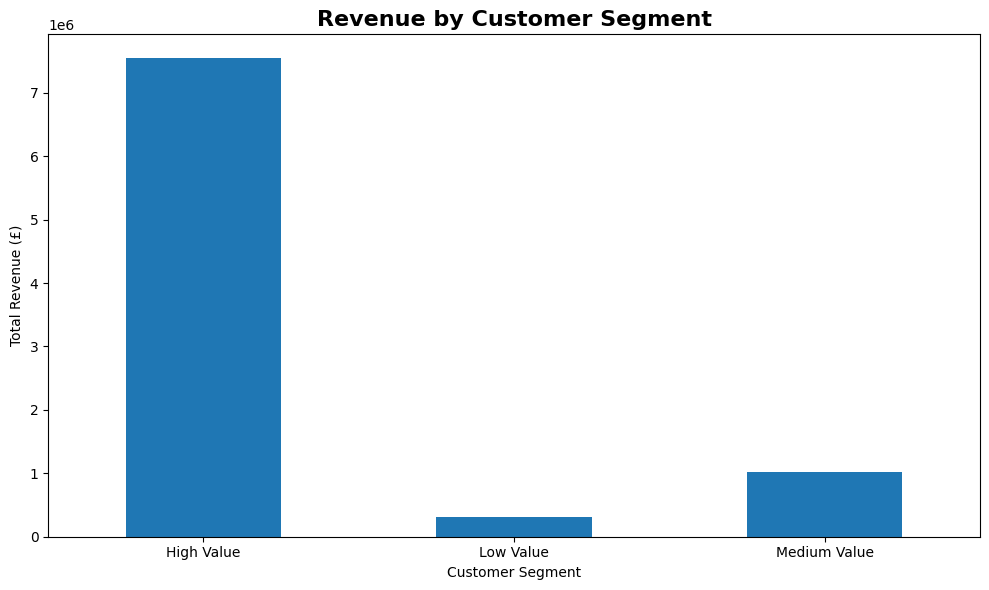

In [36]:
plt.figure(figsize=(10, 6))

segment_summary.set_index("Customer_Segment")["Total_Revenue"].plot(
    kind="bar"
)

plt.title("Revenue by Customer Segment", fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue (£)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

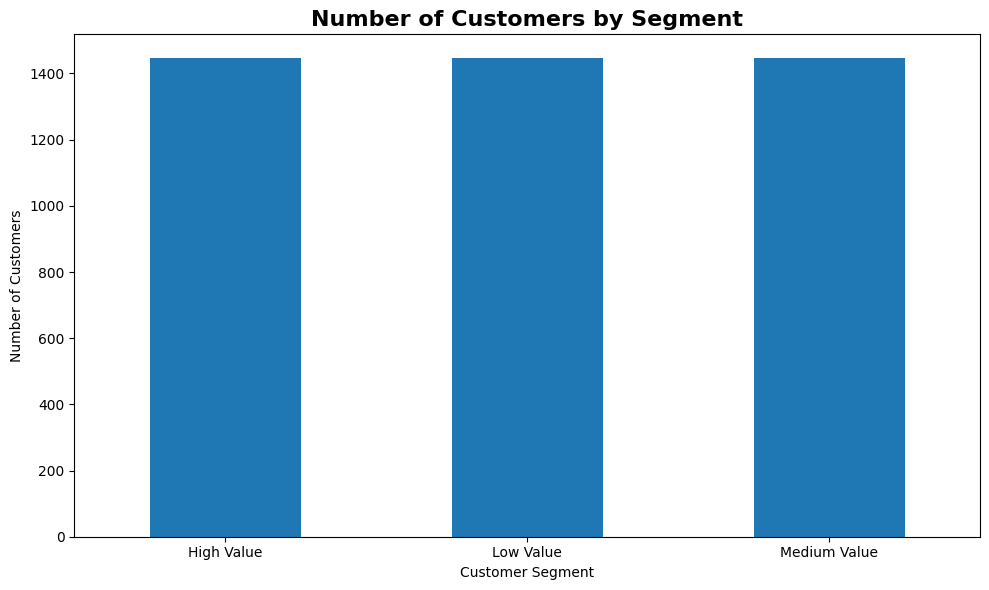

In [37]:
plt.figure(figsize=(10, 6))

segment_summary.set_index("Customer_Segment")["Customers"].plot(
    kind="bar"
)

plt.title("Number of Customers by Segment", fontsize=16, fontweight="bold")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
top_customers = customer_summary.nlargest(
    10, "Total_Revenue"
)

top_customers[
    [
        "CustomerID",
        "Total_Revenue",
        "Total_Orders",
        "Average_Order_Value",
        "Customer_Segment"
    ]
]

,CustomerID,Total_Revenue,Total_Orders,Average_Order_Value,Customer_Segment
1689,14646.0,280206.02,73,3838.438630,High Value
4201,18102.0,259657.30,60,4327.621667,High Value
3728,17450.0,194390.79,46,4225.886739,High Value
3008,16446.0,168472.50,2,84236.250000,High Value
1879,14911.0,143711.17,201,714.980945,High Value
55,12415.0,124914.53,21,5948.310952,High Value
1333,14156.0,117210.08,55,2131.092364,High Value
3771,17511.0,91062.38,31,2937.496129,High Value
2702,16029.0,80850.84,63,1283.346667,High Value
0,12346.0,77183.60,1,77183.600000,High Value


In [39]:
segment_summary.sort_values(
    "Revenue_Share_%",
    ascending=False
)

,Customer_Segment,Customers,Total_Revenue,Average_Revenue,Average_Orders,Revenue_Share_%
0,High Value,1446,7545720.931,5218.340893,8.910097,84.91
2,Medium Value,1446,1024481.293,708.493287,2.582296,11.53
1,Low Value,1446,317006.670,219.230062,1.323651,3.57


In [40]:
monthly_growth = monthly_trend.pct_change() * 100

monthly_growth = monthly_growth.round(2)

monthly_growth

,Revenue
InvoiceDate,
2010-12,NaN
2011-01,-0.41
2011-02,-21.48
2011-03,33.18
2011-04,-21.16
2011-05,44.62
2011-06,-2.56
2011-07,-9.25
2011-08,7.53


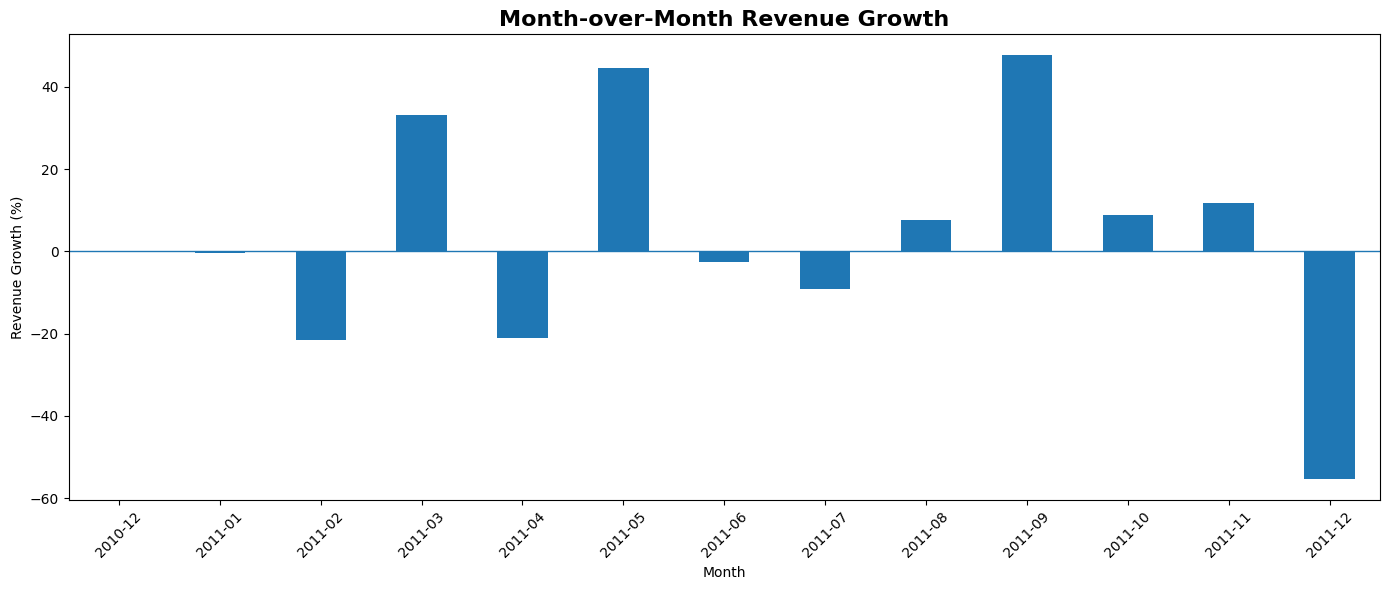

In [41]:
plt.figure(figsize=(14, 6))

monthly_growth.plot(
    kind="bar"
)

plt.title(
    "Month-over-Month Revenue Growth",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")
plt.xticks(rotation=45)

plt.axhline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [42]:
best_month = monthly_trend.idxmax()
best_month_revenue = monthly_trend.max()

lowest_month = monthly_trend.idxmin()
lowest_month_revenue = monthly_trend.min()

print(f"Highest revenue month: {best_month}")
print(f"Highest revenue: £{best_month_revenue:,.2f}")

print()

print(f"Lowest revenue month: {lowest_month}")
print(f"Lowest revenue: £{lowest_month_revenue:,.2f}")

Highest revenue month: 2011-11
Highest revenue: £1,156,205.61

Lowest revenue month: 2011-02
Lowest revenue: £446,084.92


# Business Analysis Summary

## Revenue Trends
Monthly revenue analysis was performed to identify periods of higher and lower sales activity. Month-over-month growth was also calculated to understand changes in revenue over time.

## Customer Segments
Customers were divided into Low Value, Medium Value, and High Value segments based on their total revenue contribution.

## Product Performance
Top products were identified based on total revenue to determine which products contributed most to sales.

## Geographic Performance
Countries were compared based on total revenue to identify the strongest geographic markets.

## Customer Value
Customer-level analysis was performed using total revenue, number of orders, total quantity purchased, and average order value.

## Business Intelligence
The analysis combines transaction-level sales data, customer behavior, product performance, geographic performance, and time-based trends to provide a broader view of e-commerce performance.

# Actionable Business Recommendations

### 1. Focus on High-Value Customers
High-value customers generate a significant share of revenue. The business can consider loyalty programs, personalized offers, and targeted promotions to encourage repeat purchases.

### 2. Improve Customer Retention
Customers with previous purchases can be targeted with relevant product recommendations and follow-up campaigns to encourage repeat orders.

### 3. Promote Top-Performing Products
Products generating the highest revenue can receive additional promotional attention and better visibility.

### 4. Investigate Low-Revenue Periods
Months with lower revenue should be investigated to understand whether seasonal demand, product availability, or customer activity contributed to the decline.

### 5. Monitor Revenue Trends
Monthly revenue and month-over-month growth should be monitored regularly to identify positive and negative changes early.

### 6. Develop Customer-Specific Marketing
Different customer segments can receive different marketing strategies rather than using the same promotion for every customer.

### 7. Analyze Geographic Opportunities
High-performing countries can be prioritized for marketing and expansion, while lower-performing markets can be analyzed for potential improvement opportunities.

# Conclusion

This project successfully performed an end-to-end e-commerce sales analysis using Python and Pandas.

The analysis included:

- Data cleaning and preparation
- Duplicate handling
- Date conversion
- Feature engineering
- Revenue calculation
- Year, month, day, and weekday extraction
- Key sales KPI calculation
- Monthly revenue analysis
- Month-over-month growth calculation
- Product revenue analysis
- Country revenue analysis
- Customer-level analysis
- Customer segmentation
- Pivot table analysis
- Data visualization
- Business recommendations

The analysis demonstrates how transaction data can be transformed into useful business intelligence for understanding revenue trends, customer value, product performance, and geographic sales patterns.

# Task 04 – Completion Summary

### Requirements Completed

- ✅ E-commerce sales dataset loaded
- ✅ Dataset inspected
- ✅ Missing values reviewed
- ✅ Duplicate records checked and removed
- ✅ Date column converted to datetime
- ✅ Revenue feature engineered
- ✅ Year extracted
- ✅ Month extracted
- ✅ Month name extracted
- ✅ Day extracted
- ✅ Day name extracted
- ✅ Total revenue calculated
- ✅ Total orders calculated
- ✅ Average order value calculated
- ✅ Monthly revenue trend analyzed
- ✅ Pivot table created
- ✅ Month-over-month growth calculated
- ✅ Top products identified
- ✅ Top countries identified
- ✅ Customer-level analysis performed
- ✅ Customer segments created
- ✅ Revenue by customer segment analyzed
- ✅ Business recommendations developed

### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

### Outcome

Developed practical business intelligence skills by transforming raw e-commerce transaction data into customer, product, geographic, and revenue insights.